# Project 3: Multimodal Image Generation Studio
Text descriptions ko high-quality digital artwork mein convert karne wala tool.

In [ ]:
import requests

# IPython.display - Colab ke andar image dikhane ke liye
from IPython.display import display, Image as IPImage


# urllib - prompt ko safe URL format mein convert karne ke liye
import urllib.parse

print("Libraries ready ✅")

Libraries ready ✅


In [ ]:
def generate_image_url(prompt, width=1024, height=1024):
    """
    Ye function ek text prompt leta hai aur
    Pollinations.ai se ek image URL banata hai

    prompt: image ka description (text)
    width, height: image ka resolution (pixels mein)
    """

    # Prompt ko URL-safe banate hain (spaces/special chars handle karne ke liye)
    safe_prompt = urllib.parse.quote(prompt)

    # Base URL + prompt + parameters jorr kar final URL banate hain
    image_url = f"https://image.pollinations.ai/prompt/{safe_prompt}?width={width}&height={height}&nologo=true"

    return image_url


# Test karte hain
prompt = "a futuristic city skyline at sunset, digital art"
url = generate_image_url(prompt)

print("Generated URL:")
print(url)

Generated URL:
https://image.pollinations.ai/prompt/a%20futuristic%20city%20skyline%20at%20sunset%2C%20digital%20art?width=1024&height=1024&nologo=true


🎨 Generating image for: 'a futuristic city skyline at sunset, digital art' ... please wait


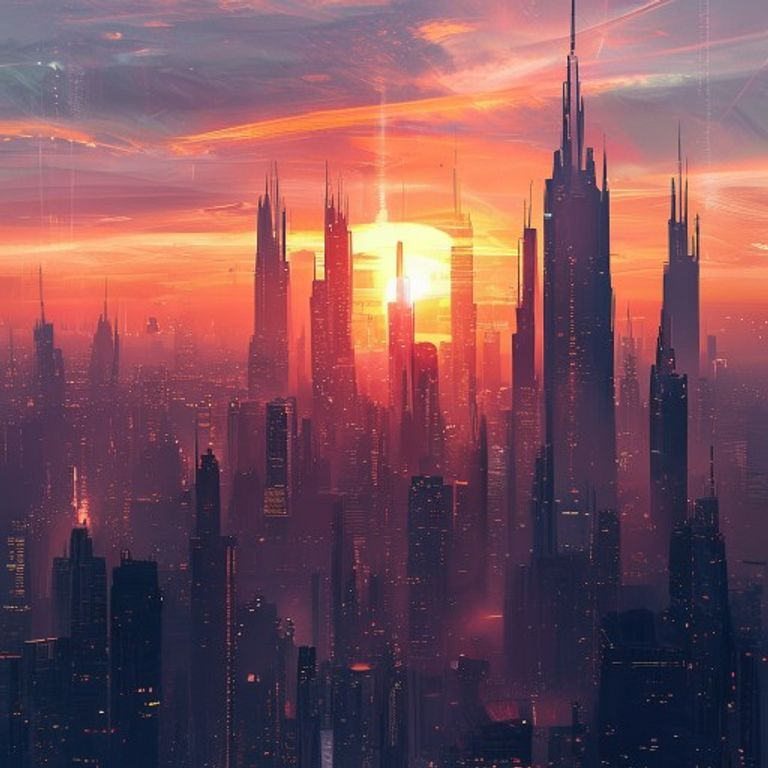

✅ Image generated successfully!


In [ ]:
def generate_and_show_image(prompt, width=1024, height=1024):
    """
    Ye function image generate karta hai AUR use turant
    Colab mein khoobsurat tareeke se dikhata bhi hai
    """

    print(f"🎨 Generating image for: '{prompt}' ... please wait")

    # URL banate hain
    image_url = generate_image_url(prompt, width, height)

    # Actual request bhejte hain server ko, aur image ka data mangwate hain
    response = requests.get(image_url, timeout=60)

    # Check karte hain ke request successful thi ya nahi
    if response.status_code == 200:
        # Image ka binary data mila - ab ise display karte hain
        display(IPImage(data=response.content, width=400))
        print("✅ Image generated successfully!")
        return response.content
    else:
        print(f"⚠️ Kuch masla ho gaya. Status code: {response.status_code}")
        return None


# Test karte hain!
image_data = generate_and_show_image("a futuristic city skyline at sunset, digital art")

In [ ]:
# Ye dictionary standard aspect ratios ko unki exact
# pixel dimensions se map karti hai (jaise PDF slide mein tha)
ASPECT_RATIOS = {
    "Square (1:1)": (1024, 1024),        # Instagram posts, avatars
    "Landscape (16:9)": (1344, 768),      # Web banners, presentations
    "Portrait (9:16)": (768, 1344),       # Mobile reels, wallpapers
}

# Test - dictionary se values nikaalna
print("Available presets:")
for name, (w, h) in ASPECT_RATIOS.items():
    print(f"  {name} → {w}x{h} pixels")

Available presets:
  Square (1:1) → 1024x1024 pixels
  Landscape (16:9) → 1344x768 pixels
  Portrait (9:16) → 768x1344 pixels


In [ ]:
import time    # wait/pause karne ke liye
import random  # random delay ("jitter") add karne ke liye

def generate_image_safe(prompt, width=1024, height=1024, max_retries=3):
    """
    Ye 'safe' version hai jo automatically retry karta hai
    agar request fail ho jaye - bilkul professional apps ki tarah

    max_retries: kitni baar dobara try karna hai (agar fail ho)
    """

    image_url = generate_image_url(prompt, width, height)

    # Loop jo max_retries baar try karega
    for attempt in range(1, max_retries + 1):
        try:
            print(f"🎨 Attempt {attempt}/{max_retries} — generating...")

            # Split timeout: 5 sec connect + 90 sec read
            # (image generation slow ho sakta hai, isliye read timeout lamba)
            response = requests.get(image_url, timeout=(5, 90))

            # Agar successful raha, turant result return karo
            if response.status_code == 200:
                print("✅ Success!")
                return response.content

            # Agar server ne koi error diya (jaise rate limit)
            print(f"⚠️ Server responded with status {response.status_code}")

        except requests.exceptions.ConnectTimeout:
            print("⚠️ Connection timeout — server tak pohanch nahi payi request")

        except requests.exceptions.ReadTimeout:
            print("⚠️ Read timeout — server bohat slow hai")

        except requests.exceptions.RequestException as e:
            print(f"⚠️ Kuch aur masla: {e}")

        # Agar ye aakhri attempt nahi hai, to thoda ruk kar dobara try karo
        if attempt < max_retries:
            wait_time = (2 ** attempt) + random.uniform(0, 1)  # exponential + jitter
            print(f"⏳ {wait_time:.1f} seconds wait karke dobara try karenge...")
            time.sleep(wait_time)

    print("❌ Sab attempts fail ho gaye. Baad mein try karein.")
    return None

In [ ]:
from PIL import Image
import io

def verify_image_integrity(image_data):
    """
    Ye check karta hai ke downloaded image
    poori aur sahi hai, ya beech mein se toot gayi hai

    Return: True agar image sahi hai, False agar corrupted hai
    """
    try:
        # Image ko memory mein khol kar poora "load" karte hain
        # (sirf header nahi, pura pixel data)
        img = Image.open(io.BytesIO(image_data))
        img.load()   # ye line poori image force-decode karti hai
        return True

    except Exception as e:
        print(f"⚠️ Image corrupted hai: {e}")
        return False


# Test - pehle wali image ko verify karte hain
if image_data:
    is_valid = verify_image_integrity(image_data)
    print(f"Image valid hai? {is_valid}")

Image valid hai? True


🎨 Attempt 1/3 — generating...
✅ Success!


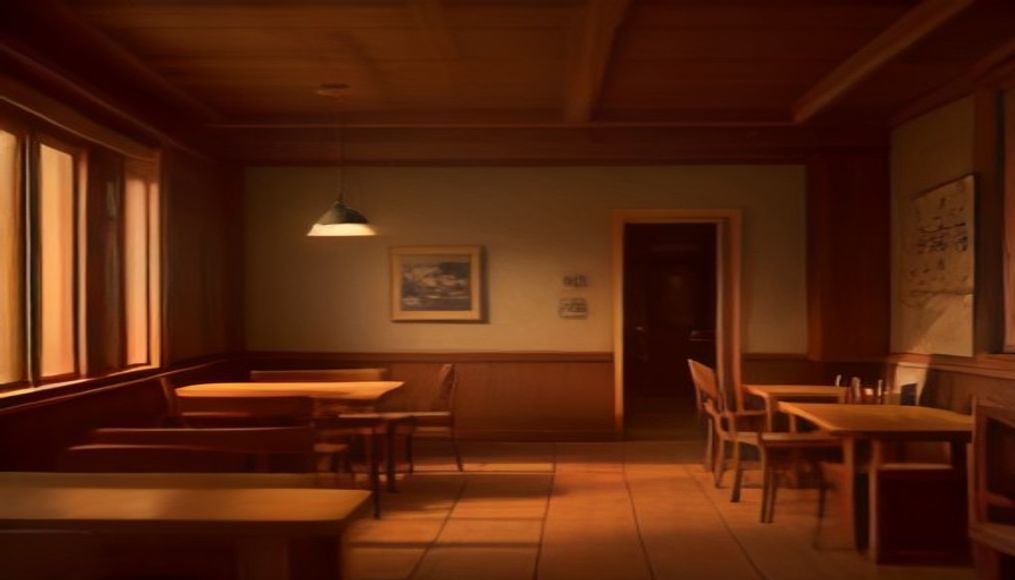

✅ 'a cozy coffee shop interior, warm lighting, digital painting' — Landscape (16:9) (1344x768) — Verified & Ready!


In [ ]:
def generate_image_pro(prompt, aspect_ratio="Square (1:1)"):
    """
    Ye humara FINAL professional function hai jo:
    1. Aspect ratio preset use karta hai
    2. Retry logic ke sath generate karta hai
    3. Integrity verify karta hai
    4. Beautiful output dikhata hai
    """

    # Preset se width/height nikaalna
    width, height = ASPECT_RATIOS[aspect_ratio]

    # Image generate karna (retry logic ke sath)
    image_data = generate_image_safe(prompt, width, height)

    if image_data is None:
        print("❌ Image generate nahi ho payi.")
        return None

    # Integrity check
    if not verify_image_integrity(image_data):
        print("❌ Image corrupted nikli, dobara try karein.")
        return None

    # Sab theek — ab display karte hain
    display(IPImage(data=image_data, width=450))
    print(f"✅ '{prompt}' — {aspect_ratio} ({width}x{height}) — Verified & Ready!")

    return image_data


# Poora test
result = generate_image_pro(
    prompt="a cozy coffee shop interior, warm lighting, digital painting",
    aspect_ratio="Landscape (16:9)"
)

✅ Success!


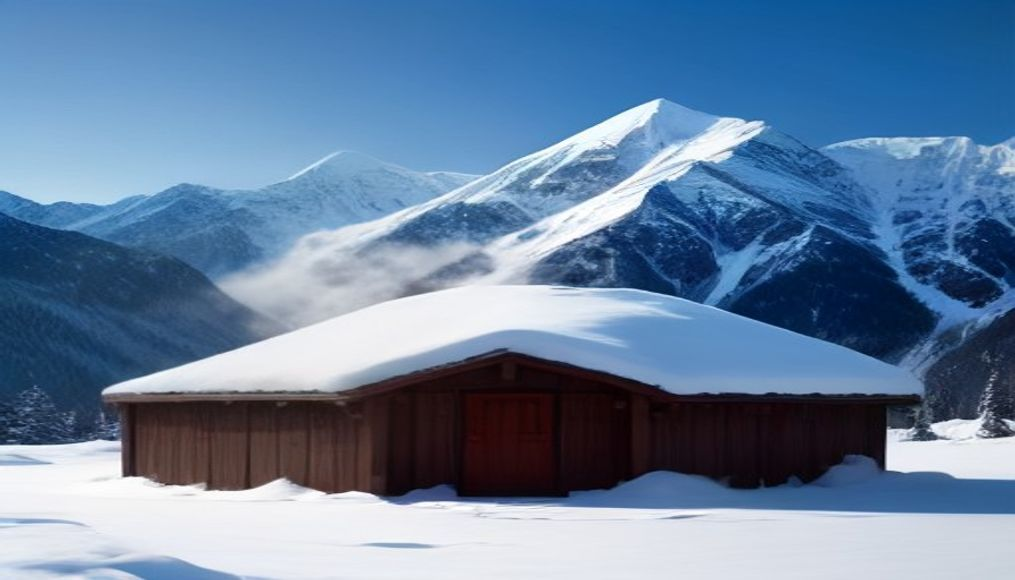

✅ 'asmall bautiful hut on mountains with snow around' — Landscape (16:9) (1344x768) — Verified & Ready!


Text(value='a serene mountain lake at sunrise, digital art', description='Prompt:', layout=Layout(width='500px…

Dropdown(description='Aspect Ratio:', options=('Square (1:1)', 'Landscape (16:9)', 'Portrait (9:16)'), style=D…

Dropdown(description='Style:', options=('None', 'Cyberpunk', 'Minimalism', 'Watercolor', 'Cinematic', 'Anime')…

Button(button_style='success', description='✨ Generate Image', layout=Layout(height='40px', width='220px'), st…

🎨 Attempt 1/3 — generating...
✅ Success!


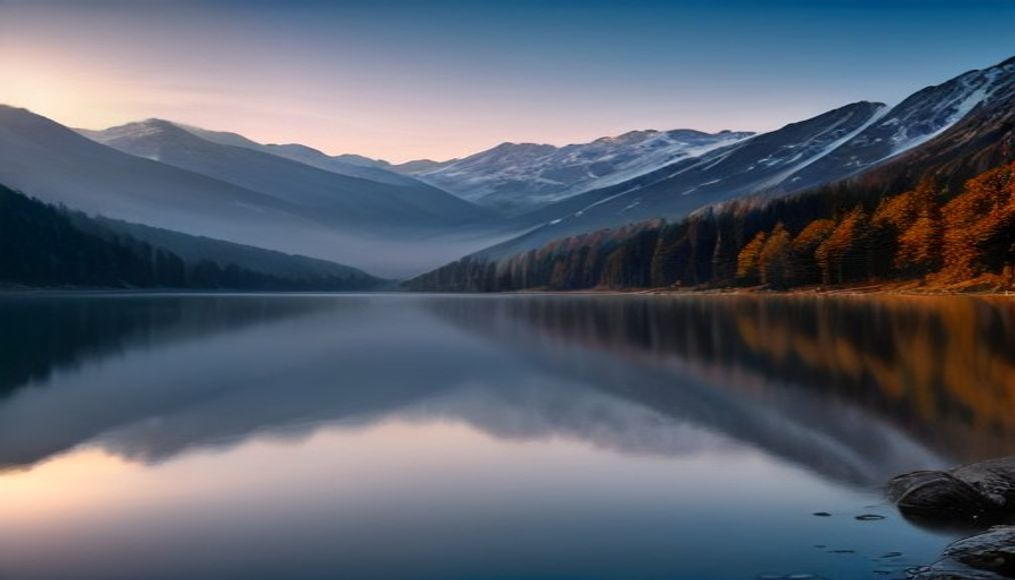

✅ 'a serene mountain lake at sunrise, digital art' — Landscape (16:9) (1344x768) — Verified & Ready!


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

# ---------- WIDGETS ----------
prompt_input = widgets.Text(
    value='a serene mountain lake at sunrise, digital art',
    placeholder='Apni image ka description likhein',
    description='Prompt:',
    layout=widgets.Layout(width='500px'),
    style={'description_width': 'initial'}
)

ratio_input = widgets.Dropdown(
    options=list(ASPECT_RATIOS.keys()),
    value='Square (1:1)',
    description='Aspect Ratio:',
    style={'description_width': 'initial'}
)

style_input = widgets.Dropdown(
    options=['None', 'Cyberpunk', 'Minimalism', 'Watercolor', 'Cinematic', 'Anime'],
    value='None',
    description='Style:',
    style={'description_width': 'initial'}
)

generate_btn = widgets.Button(
    description='✨ Generate Image',
    button_style='success',
    layout=widgets.Layout(width='220px', height='40px')
)

# ---------- BUTTON LOGIC (Output() widget ke bina) ----------
def on_generate_click(b):
    user_prompt = prompt_input.value
    aspect_ratio = ratio_input.value
    style = style_input.value

    if not user_prompt.strip():
        display(HTML("<p style='color:red;'>⚠️ Please pehle koi prompt likhein!</p>"))
        return

    final_prompt = apply_style(user_prompt, style)

    display(HTML(f"""
        <div style='padding:10px; background:#FFF3CD; border-radius:8px; font-family:sans-serif;'>
        ⏳ Generating: <b>{user_prompt}</b> ({aspect_ratio}, {style} style)...
        </div>
    """))

    result = generate_image_pro(final_prompt, aspect_ratio)

    if result:
        display(HTML(f"""
            <div style='border-left:6px solid #4A90E2; background:#f9f9f9;
                        padding:15px; border-radius:10px; font-family:sans-serif; margin-top:8px;'>
                <b style='color:#4A90E2;'>✨ Generated Successfully</b><br>
                <span style='color:#555; font-size:13px;'>
                    Prompt: {user_prompt} | Style: {style} | Ratio: {aspect_ratio}
                </span>
            </div>
        """))
    else:
        display(HTML("<p style='color:red;'>❌ Generate nahi ho payi. Dobara try karein.</p>"))

generate_btn.on_click(on_generate_click)

# ---------- DISPLAY ----------
display(prompt_input, ratio_input, style_input, generate_btn)

In [ ]:
# Har style ke liye extra descriptive keywords
STYLE_MODIFIERS = {
    'None': '',
    'Cyberpunk': ', cyberpunk style, neon lights, futuristic, high contrast',
    'Minimalism': ', minimalist style, clean lines, simple, negative space',
    'Watercolor': ', watercolor painting style, soft edges, artistic',
    'Cinematic': ', cinematic lighting, dramatic, movie still, 8k',
    'Anime': ', anime style, vibrant colors, detailed illustration',
}

def apply_style(prompt, style):
    """
    User ke prompt ke sath style modifier jorta hai
    """
    modifier = STYLE_MODIFIERS.get(style, '')
    return prompt + modifier


# Test
test_prompt = apply_style("a cat sitting on a windowsill", "Cyberpunk")
print(test_prompt)

a cat sitting on a windowsill, cyberpunk style, neon lights, futuristic, high contrast


🎨 Attempt 1/3 — generating...
✅ Success!


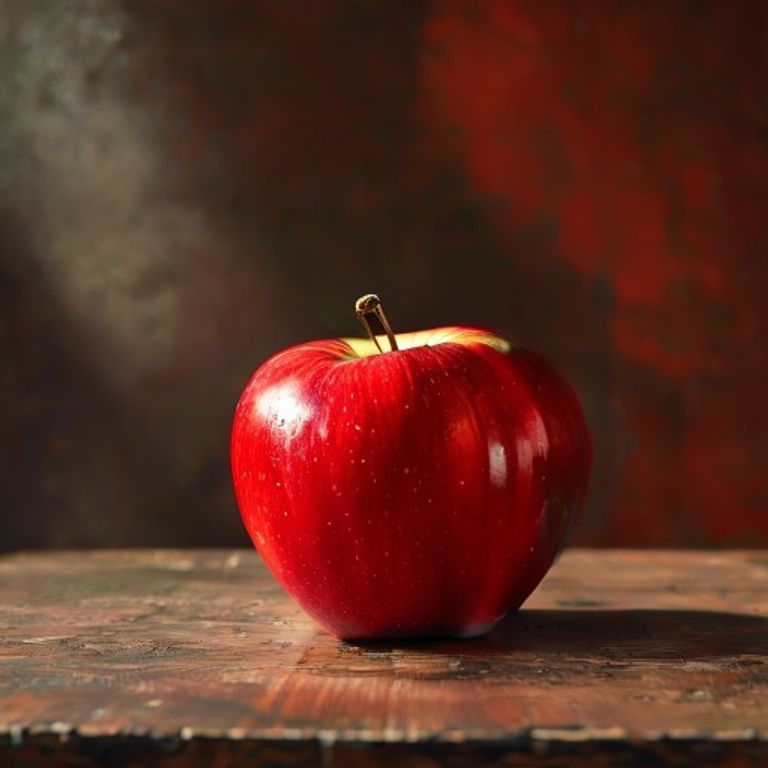

✅ 'a red apple on a table' — Square (1:1) (1024x1024) — Verified & Ready!


In [ ]:
test = generate_image_pro("a red apple on a table", "Square (1:1)")